# ABCNG Ablation Runner
This notebook runs ablation variants and saves results into per-variant folders under `figs/ablation_runs/`.


## Setup and Suite


Defines the benchmark functions, dimensions, and evaluation budget used across all runs.


In [9]:
from tools.ablation import run_ablation_suite

functions = ["sphere", "rastrigin", "rosenbrock", "ackley", "griewank", "schwefel"]
dims = [30, 50]
suite = [(fn, d, 3000 * d) for fn in functions for d in dims]

base_out = "figs/ablation_runs"


## Variants


Lists the algorithm variants (component removals and alternatives) that will be evaluated.


In [10]:
variants = [
    ("abc", "abc", None),
    ("abcng_full", "abcng", {}),
    ("no_gbest", "abcng", {"use_gbest": False}),
    ("no_adaptive_k", "abcng", {"use_adaptive_k": False}),
    ("no_gaussian", "abcng", {"use_gaussian": False}),
    ("self_in_eq7", "abcng", {"neighbor_mode": "self"}),
    ("single_dim_update", "abcng", {"update_dim_mode": "single"}),
    ("noise_cauchy", "abcng", {"noise_model": "cauchy"}),
    ("noise_uniform", "abcng", {"noise_model": "uniform"}),
    ("no_gbest_no_adaptive_k", "abcng", {"use_gbest": False, "use_adaptive_k": False}),
    ("no_gbest_no_gaussian", "abcng", {"use_gbest": False, "use_gaussian": False}),
    ("no_adaptive_k_no_gaussian", "abcng", {"use_adaptive_k": False, "use_gaussian": False}),
    ("no_gbest_no_adaptive_k_no_gaussian", "abcng", {"use_gbest": False, "use_adaptive_k": False, "use_gaussian": False}),
    ("self_in_eq7_no_gbest", "abcng", {"neighbor_mode": "self", "use_gbest": False}),
    ("self_in_eq7_no_gaussian", "abcng", {"neighbor_mode": "self", "use_gaussian": False}),
]


## Run Ablations


Runs each variant, saves CSVs and plots into per-variant subfolders under `figs/ablation_runs/`.


In [11]:
import os

FORCE_RERUN = False  # set True to retrain and overwrite results

for name, algo, kwargs in variants:
    print("Running", name)
    out_dir = f"{base_out}/{name}"
    runs_path = os.path.join(out_dir, "runs.csv")
    if os.path.exists(runs_path) and not FORCE_RERUN:
        print(f"Skipping {name}, results already exist: {runs_path}")
        continue
    v = [{"name": name, "algo": algo, "abcng_kwargs": kwargs or {}}]
    if algo == "abcng":
        v[0]["abcng_kwargs"] = {"paper_mode": True, **(kwargs or {})}
    df, _ = run_ablation_suite(
        suite,
        variants=v,
        runs=15,
        pop_size=50,
        out_dir=out_dir,
    )
    display(df.head())
    print("Saved ->", out_dir)


Running abc
Skipping abc, results already exist: figs/ablation_runs/abc/runs.csv
Running abcng_full
Skipping abcng_full, results already exist: figs/ablation_runs/abcng_full/runs.csv
Running no_gbest
Skipping no_gbest, results already exist: figs/ablation_runs/no_gbest/runs.csv
Running no_adaptive_k
Skipping no_adaptive_k, results already exist: figs/ablation_runs/no_adaptive_k/runs.csv
Running no_gaussian
Skipping no_gaussian, results already exist: figs/ablation_runs/no_gaussian/runs.csv
Running self_in_eq7
Skipping self_in_eq7, results already exist: figs/ablation_runs/self_in_eq7/runs.csv
Running single_dim_update
Skipping single_dim_update, results already exist: figs/ablation_runs/single_dim_update/runs.csv
Running noise_cauchy
Skipping noise_cauchy, results already exist: figs/ablation_runs/noise_cauchy/runs.csv
Running noise_uniform
Skipping noise_uniform, results already exist: figs/ablation_runs/noise_uniform/runs.csv
Running no_gbest_no_adaptive_k
Skipping no_gbest_no_adapti

## Comparison Plots


Aggregates `runs.csv` from all variants and generates cross-variant comparison plots and a summary CSV.


Saved figs/ablation_runs/compare/summary_compare.csv
Saved figs/ablation_runs/compare/box_ackley_D30.png
Saved figs/ablation_runs/compare/box_ackley_D50.png


/var/folders/tr/qf2k71v174q9gqbltv8g86qm0000gn/T/ipykernel_25241/1609773513.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)
/var/folders/tr/qf2k71v174q9gqbltv8g86qm0000gn/T/ipykernel_25241/1609773513.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)
/var/folders/tr/qf2k71v174q9gqbltv8g86qm0000gn/T/ipykernel_25241/1609773513.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)


Saved figs/ablation_runs/compare/box_griewank_D30.png
Saved figs/ablation_runs/compare/box_griewank_D50.png


/var/folders/tr/qf2k71v174q9gqbltv8g86qm0000gn/T/ipykernel_25241/1609773513.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)
/var/folders/tr/qf2k71v174q9gqbltv8g86qm0000gn/T/ipykernel_25241/1609773513.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)


Saved figs/ablation_runs/compare/box_rastrigin_D30.png
Saved figs/ablation_runs/compare/box_rastrigin_D50.png
Saved figs/ablation_runs/compare/box_rosenbrock_D30.png


...

Saved figs/ablation_runs/compare/box_rosenbrock_D50.png
Saved figs/ablation_runs/compare/box_schwefel_D30.png


/var/folders/tr/qf2k71v174q9gqbltv8g86qm0000gn/T/ipykernel_25241/1609773513.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)
/var/folders/tr/qf2k71v174q9gqbltv8g86qm0000gn/T/ipykernel_25241/1609773513.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)


Saved figs/ablation_runs/compare/box_schwefel_D50.png
Saved figs/ablation_runs/compare/box_sphere_D30.png


/var/folders/tr/qf2k71v174q9gqbltv8g86qm0000gn/T/ipykernel_25241/1609773513.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)
/var/folders/tr/qf2k71v174q9gqbltv8g86qm0000gn/T/ipykernel_25241/1609773513.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)


Saved figs/ablation_runs/compare/box_sphere_D50.png


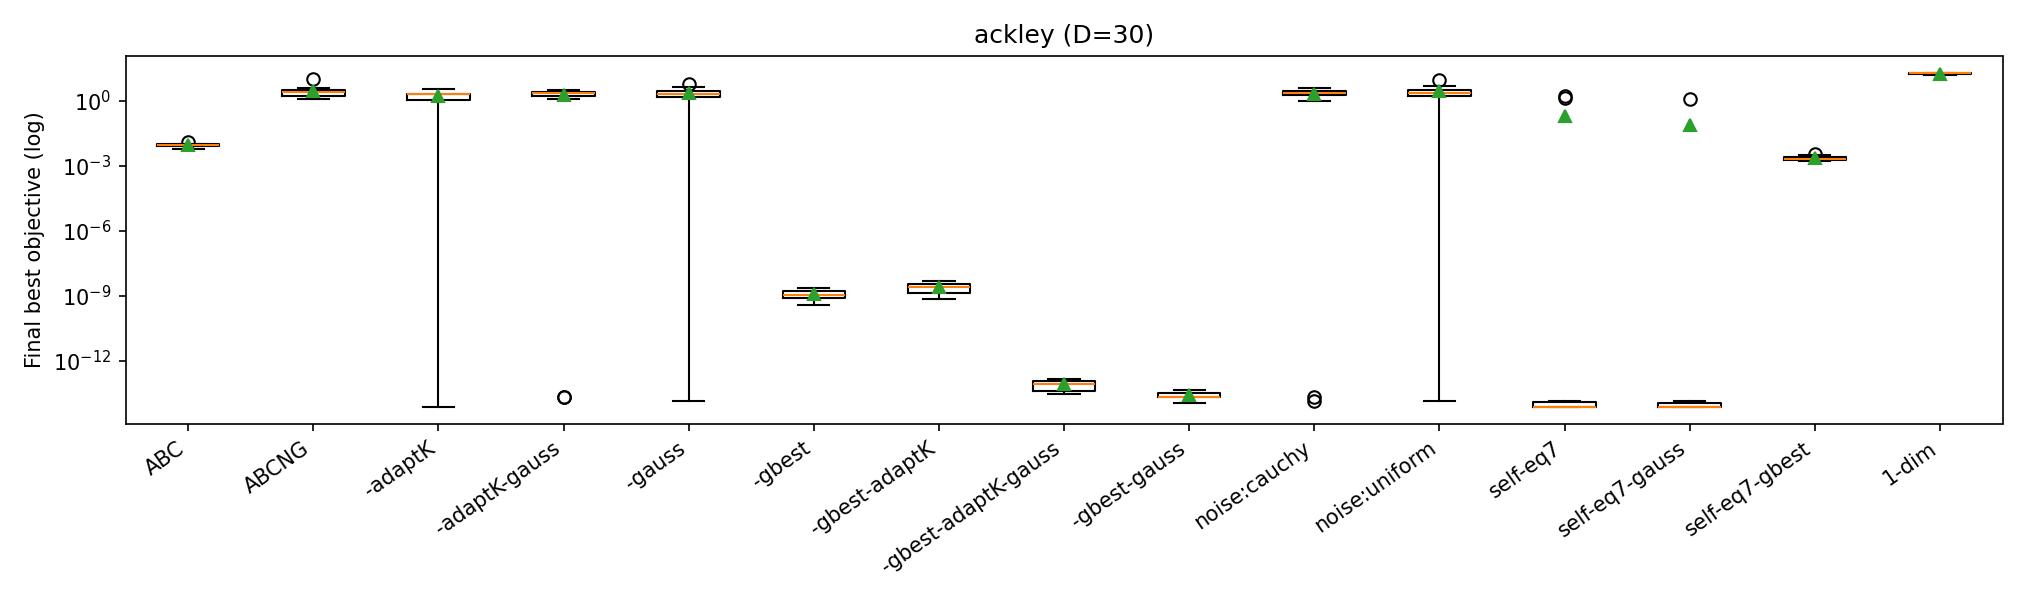

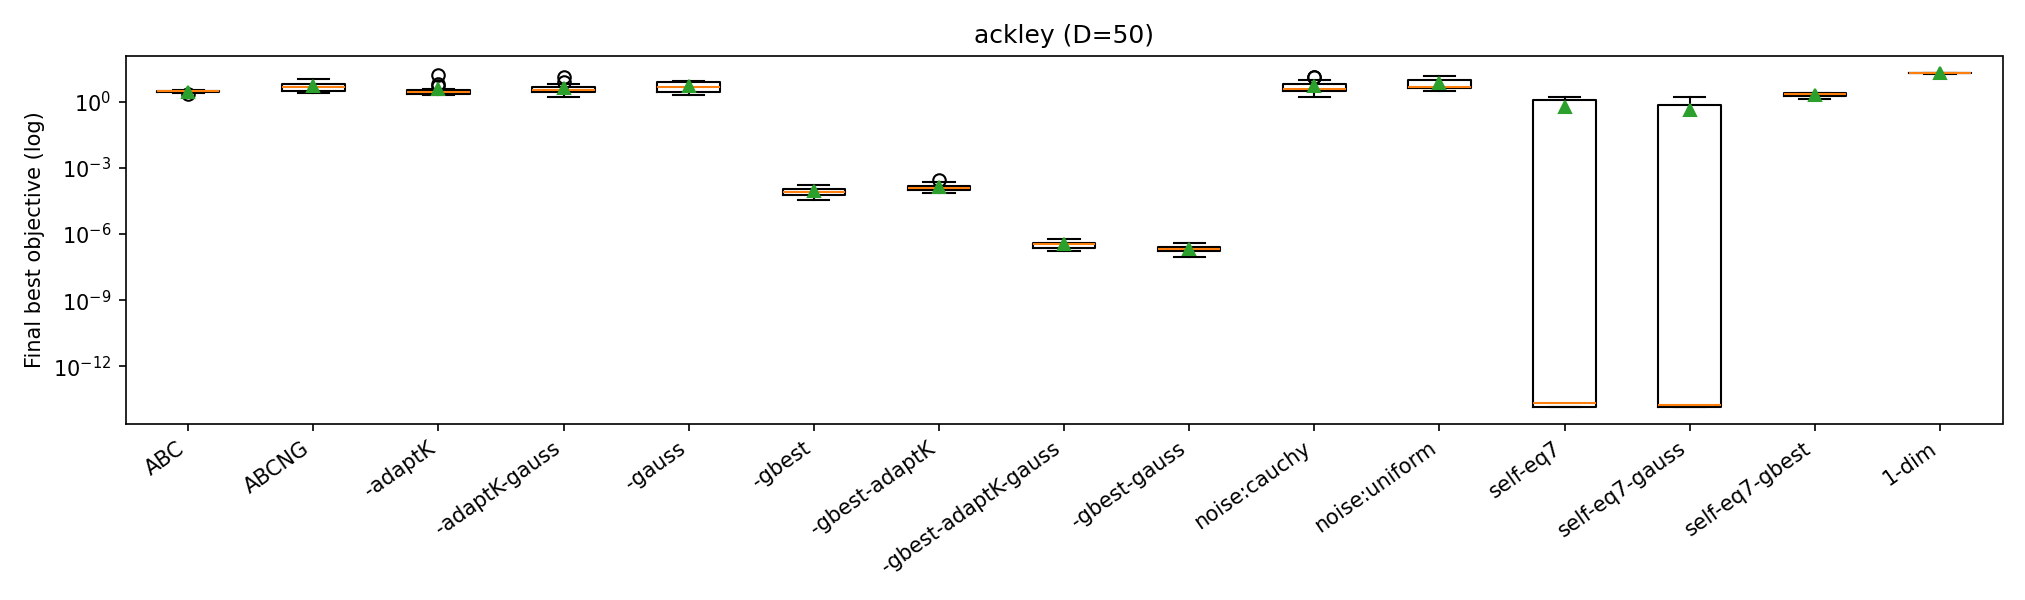

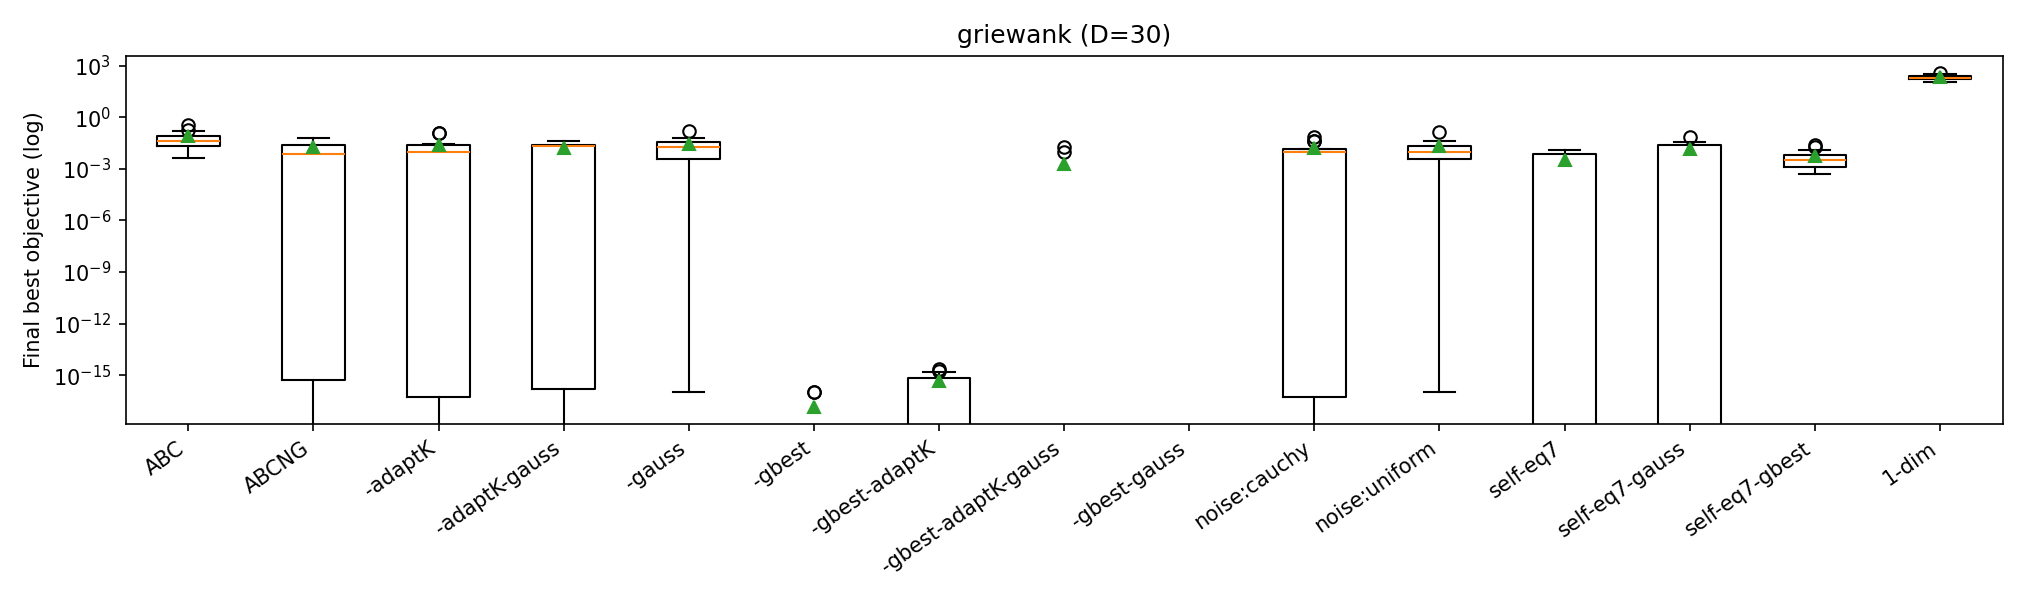

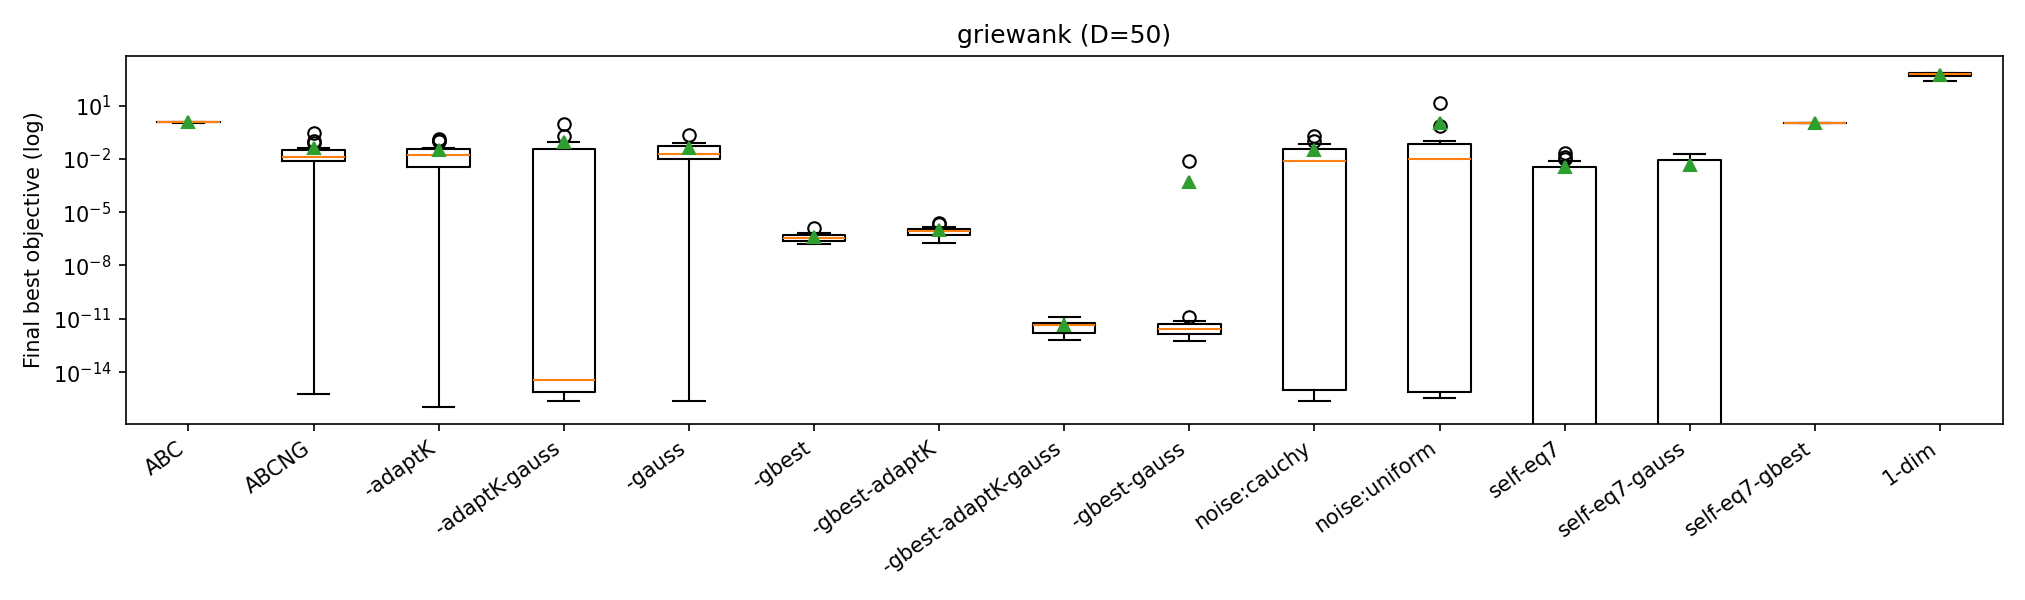

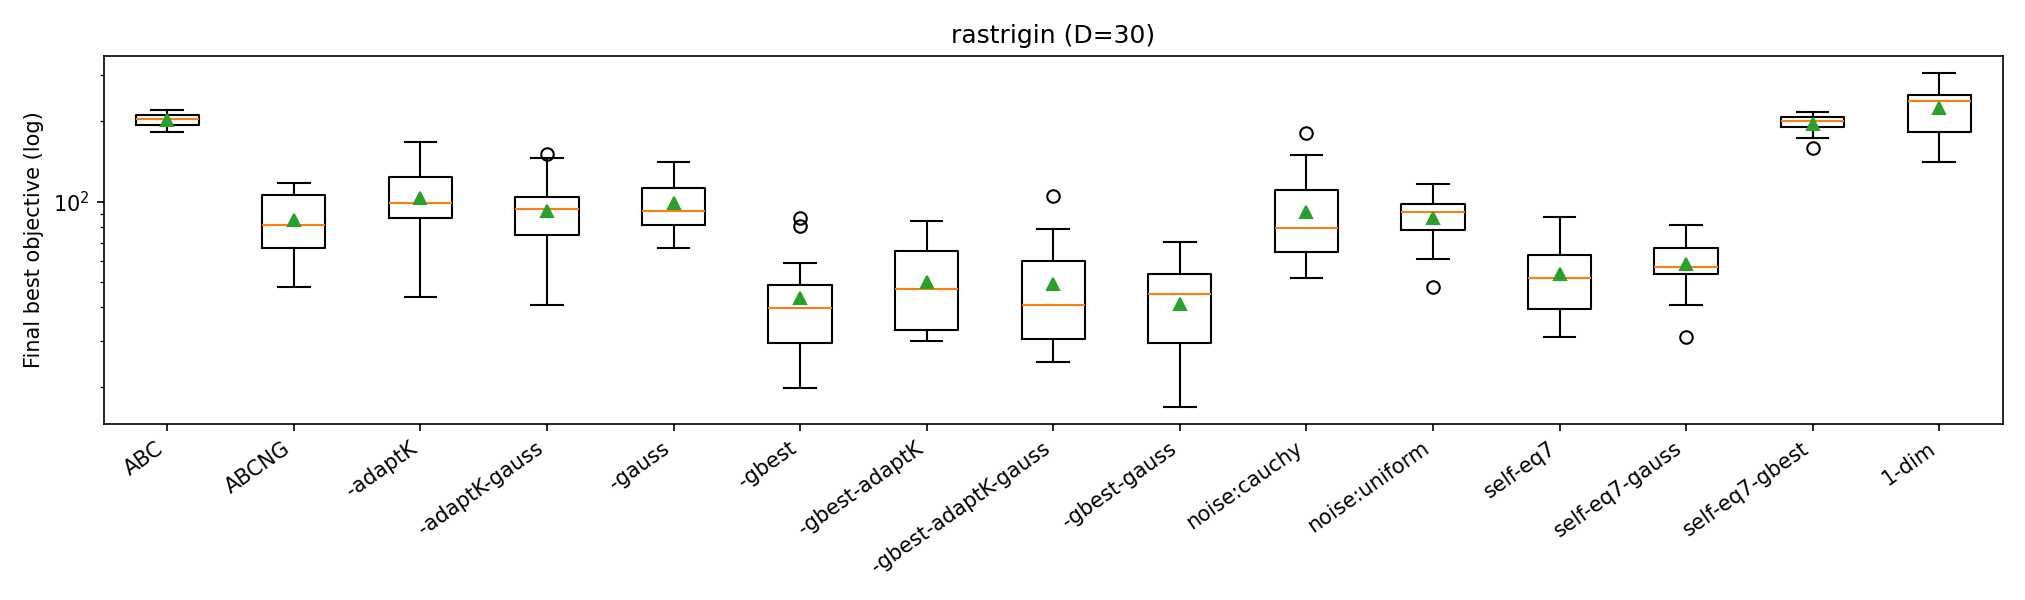

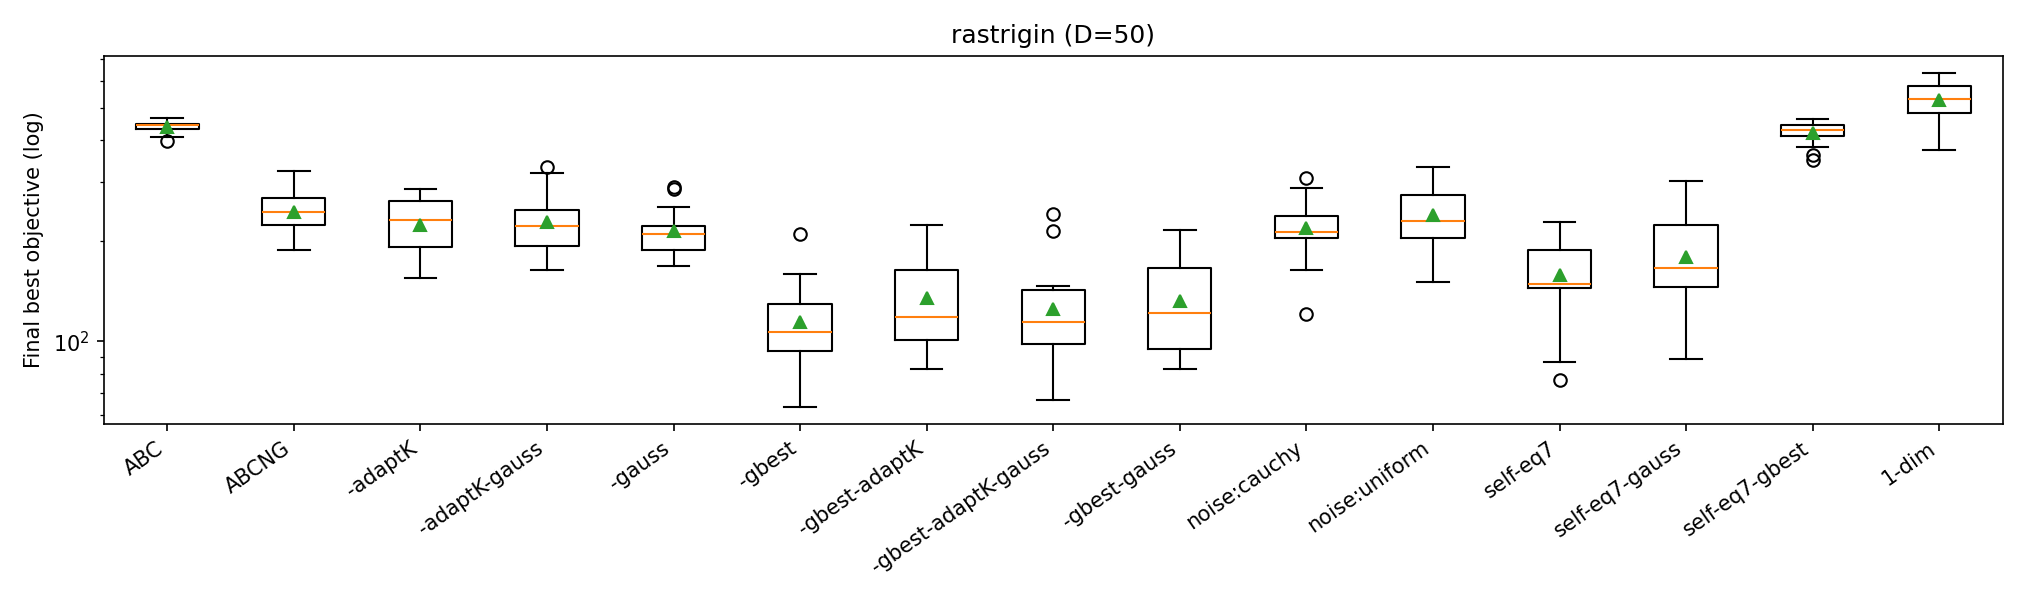

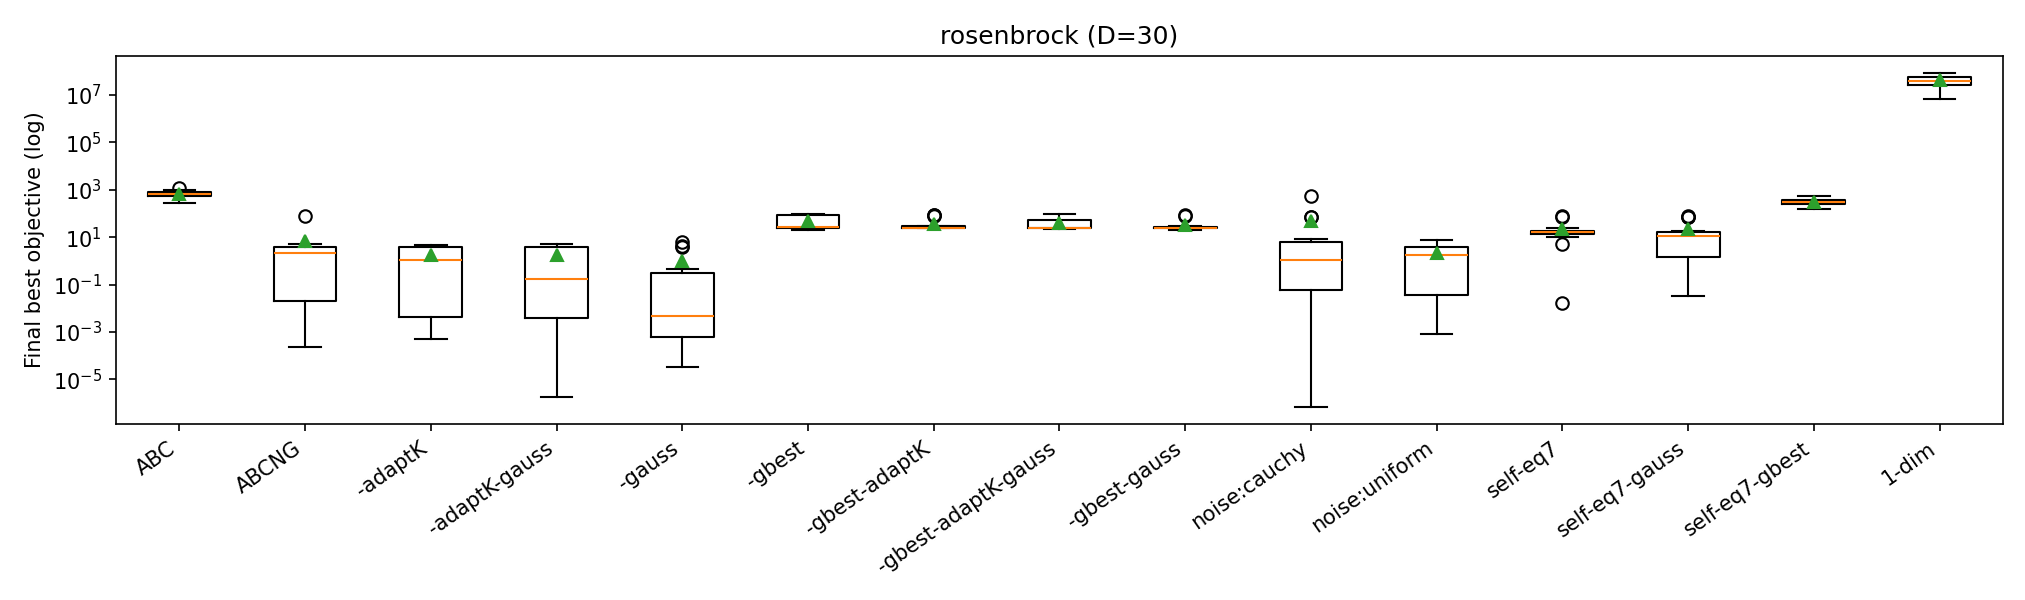

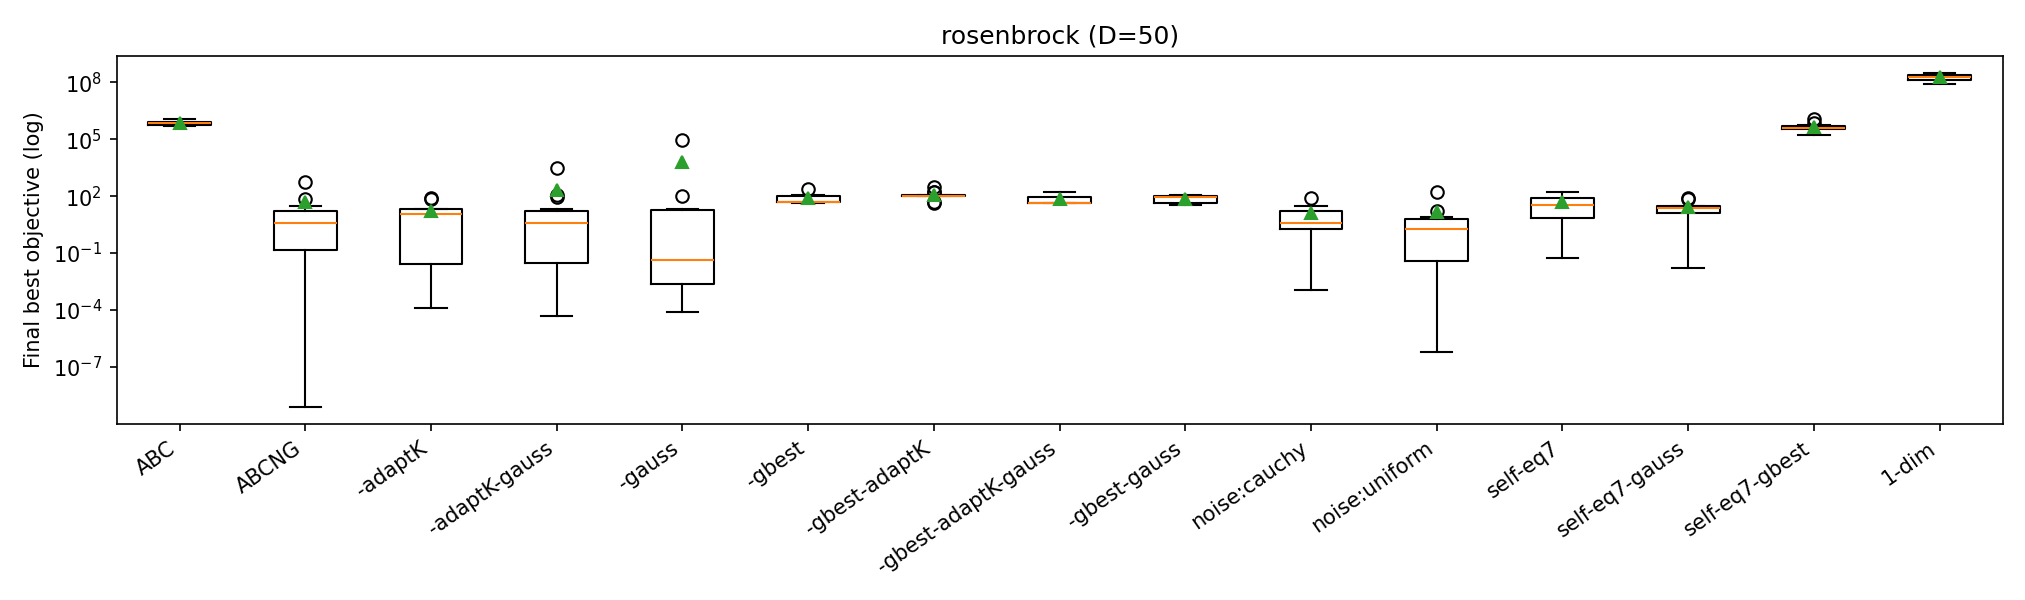

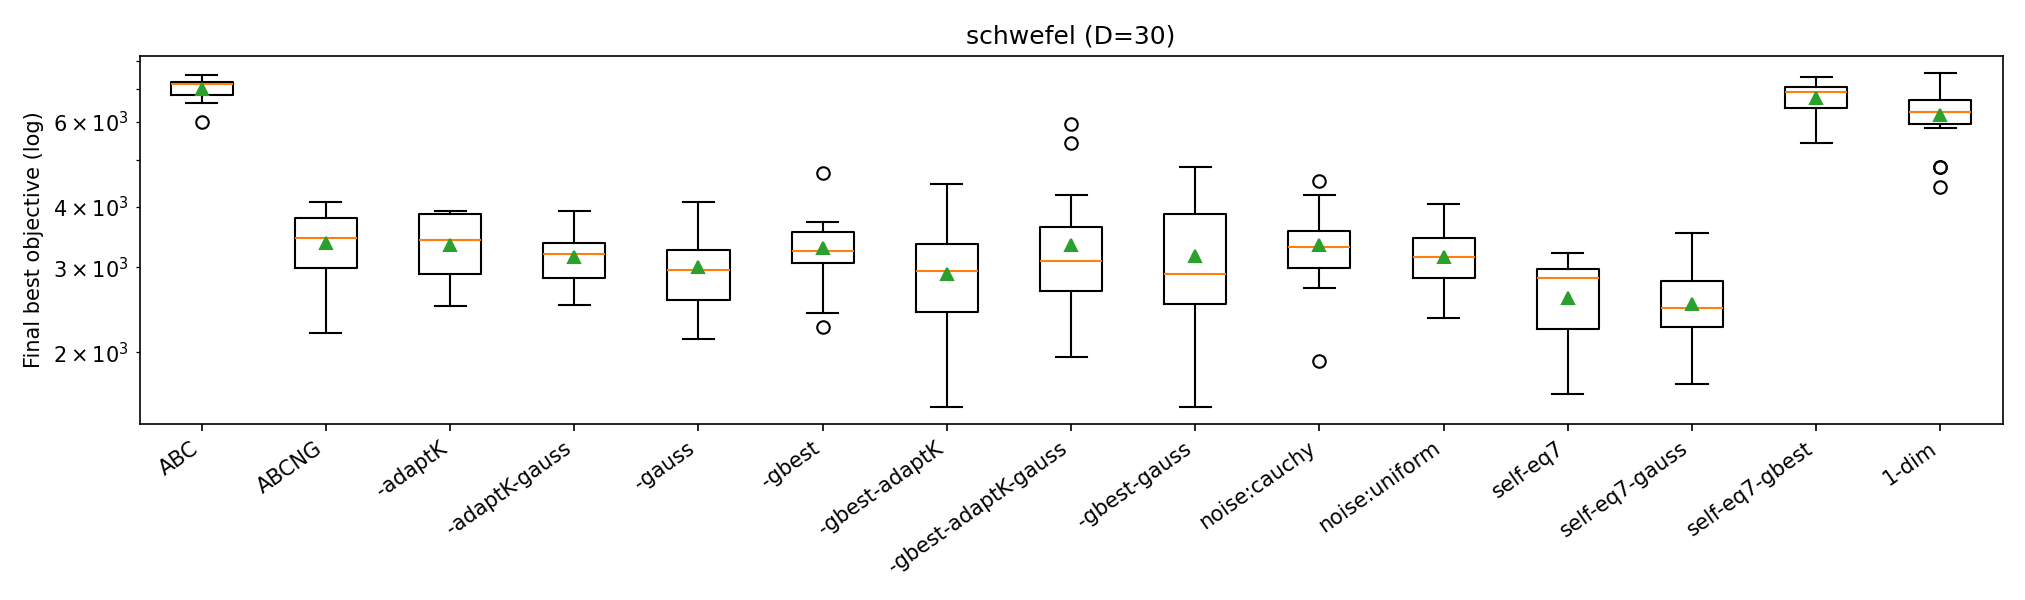

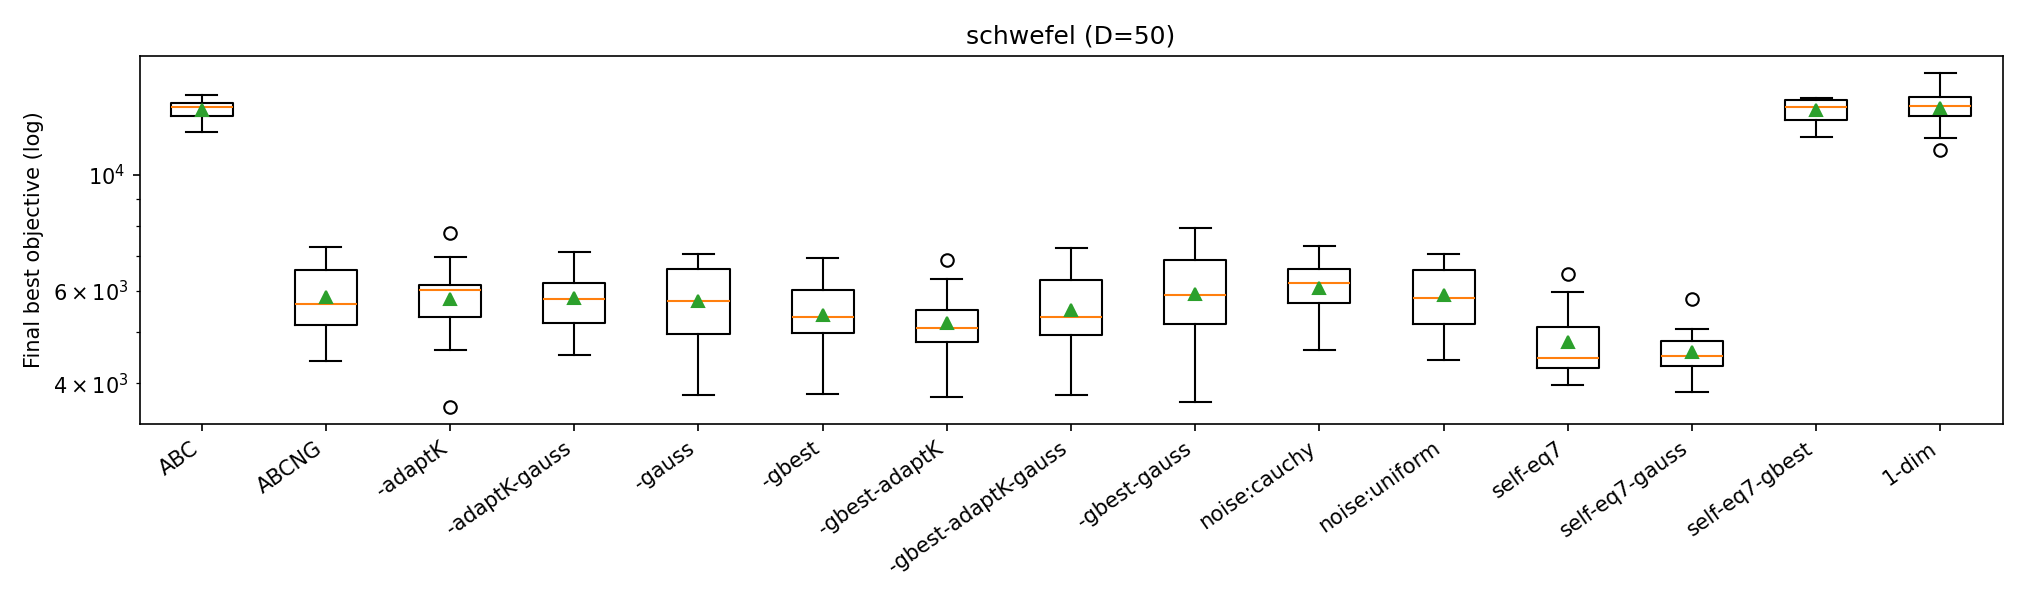

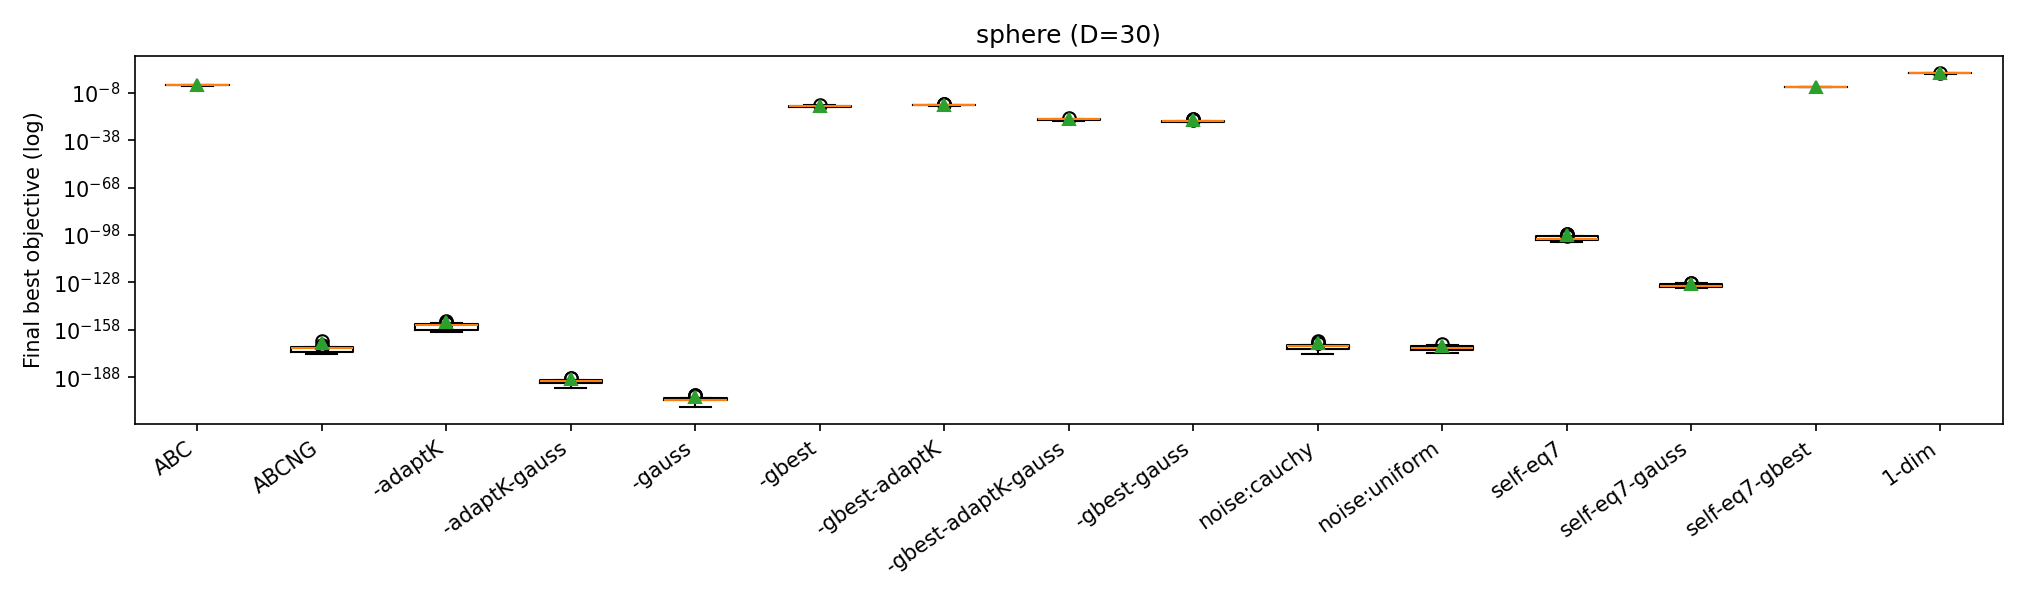

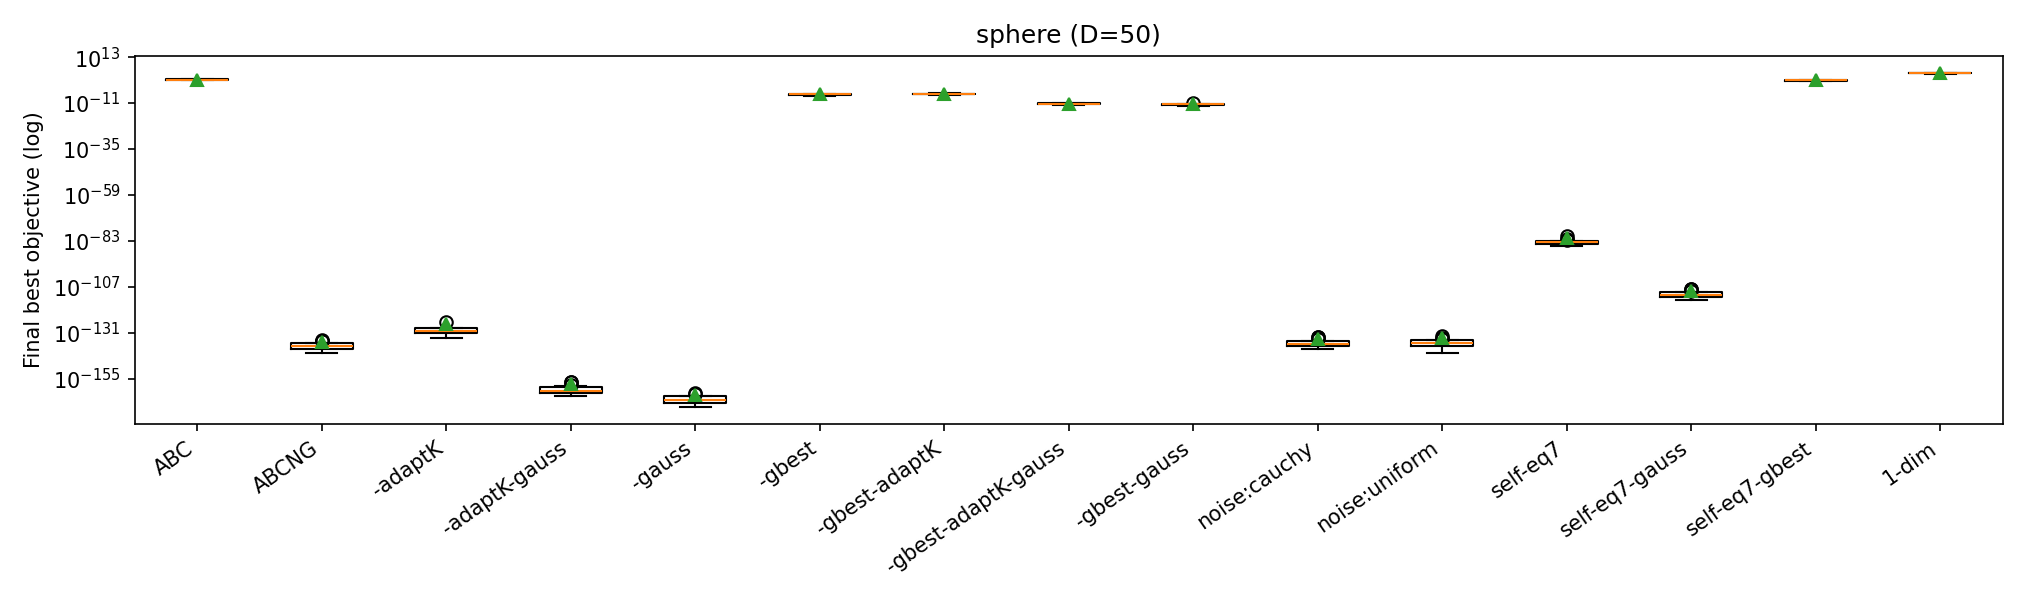

In [12]:
# Comparison plots across variants (boxplots per function/dim)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image

compare_dir = os.path.join(base_out, "compare")
os.makedirs(compare_dir, exist_ok=True)

label_map = {
    "abc": "ABC",
    "abcng_full": "ABCNG",
    "no_gbest": "-gbest",
    "no_adaptive_k": "-adaptK",
    "no_gaussian": "-gauss",
    "self_in_eq7": "self-eq7",
    "single_dim_update": "1-dim",
    "noise_cauchy": "noise:cauchy",
    "noise_uniform": "noise:uniform",
    "no_gbest_no_adaptive_k": "-gbest-adaptK",
    "no_gbest_no_gaussian": "-gbest-gauss",
    "no_adaptive_k_no_gaussian": "-adaptK-gauss",
    "no_gbest_no_adaptive_k_no_gaussian": "-gbest-adaptK-gauss",
    "self_in_eq7_no_gbest": "self-eq7-gbest",
    "self_in_eq7_no_gaussian": "self-eq7-gauss",
}

frames = []
for name, _, _ in variants:
    runs_path = os.path.join(base_out, name, "runs.csv")
    if not os.path.exists(runs_path):
        print(f"Missing runs.csv for {name}: {runs_path}")
        continue
    df = pd.read_csv(runs_path)
    df["variant"] = name
    frames.append(df)

all_runs = pd.concat(frames, ignore_index=True)

# Aggregate summary table
summary = (
    all_runs.groupby(["function", "dim", "variant"])["final_best"]
    .agg(["median", "mean", "std"])
    .reset_index()
)
summary_path = os.path.join(compare_dir, "summary_compare.csv")
summary.to_csv(summary_path, index=False)
print("Saved", summary_path)

# Boxplots per function/dim across variants
plot_paths = []
for (fn, d), group in all_runs.groupby(["function", "dim"]):
    labels = []
    data = []
    for vname, vgroup in group.groupby("variant"):
        labels.append(label_map.get(vname, vname))
        data.append(vgroup["final_best"].values)

    plt.figure(figsize=(max(8, len(labels) * 0.9), 4))
    plt.boxplot(data, labels=labels, showmeans=True)
    plt.yscale("log")
    plt.ylabel("Final best objective (log)")
    plt.title(f"{fn} (D={d})")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    out = os.path.join(compare_dir, f"box_{fn}_D{d}.png")
    plt.savefig(out, dpi=150)
    plt.close()
    plot_paths.append(out)
    print("Saved", out)

# Display plots inline
for p in plot_paths:
    display(Image(filename=p))


## Summary for Presentation


In [13]:
# Summary stats: median across functions/dims and win/tie/loss vs ABCNG
import os
import pandas as pd
import numpy as np

summary_path = os.path.join(base_out, "compare", "summary_compare.csv")
if not os.path.exists(summary_path):
    raise FileNotFoundError(summary_path)
summary = pd.read_csv(summary_path)

# Median final score per variant (aggregate over all functions/dims)
variant_medians = (
    summary.groupby("variant")["median"]
    .median()
    .sort_values()
)
display(variant_medians.to_frame("median_final_across_all"))

# Win/Tie/Loss vs ABCNG baseline (lower is better)
baseline = "abcng_full"
pivot = summary.pivot_table(index=["function", "dim"], columns="variant", values="median")
if baseline not in pivot.columns:
    raise ValueError(f"Baseline {baseline} not found in summary_compare.csv")

def wtl(col):
    b = pivot[baseline]
    v = pivot[col]
    win = int((v < b).sum())
    tie = int((v == b).sum())
    loss = int((v > b).sum())
    return pd.Series({"win": win, "tie": tie, "loss": loss})

wtl_table = pivot.columns.to_series().apply(wtl)
display(wtl_table.sort_values(["win", "loss"], ascending=[False, True]))


,median_final_across_all
variant,
no_gaussian,1.081848
noise_uniform,2.035734
no_adaptive_k,2.390297
no_adaptive_k_no_gaussian,2.812440
noise_cauchy,2.961438
abcng_full,3.246692
self_in_eq7_no_gaussian,5.512224
self_in_eq7,8.022858
no_gbest_no_gaussian,11.983596


,win,tie,loss
variant,,,
no_adaptive_k_no_gaussian,9,0,3
no_gbest,8,0,4
no_gbest_no_adaptive_k,8,0,4
no_gbest_no_adaptive_k_no_gaussian,8,0,4
self_in_eq7,8,0,4
self_in_eq7_no_gaussian,8,0,4
no_gaussian,7,0,5
no_gbest_no_gaussian,7,0,5
noise_cauchy,7,0,5
